# MLP for Time Series Classification — Experiments 3.0
## 2× Width Scaling Study (Wang, Yan & Oates, 2016)

---

### Areas for improvement in the original MLP reproduction

| # | Issue | Fix |
|---|-------|-----|
| 1 | Code duplicated per dataset | Modular pipeline |
| 2 | Only `np.random.seed` set | Seed all RNGs |
| 3 | Label encoding via min-max formula | `LabelEncoder` |
| 4 | Float batch_size `shape[0]/10` | Integer `//` |
| 5 | No early stopping; min training loss selection | Early stopping on `val_loss` |
| 6 | `ReduceLROnPlateau min_lr=0.1` (potentially too high) | Lowered to `1e-4` |
| 7 | Adadelta LR discrepancy (paper 0.1, code 1.0) | Test both |
| 8 | Single seed, no variance reporting | Multi-seed runs |
| 9 | No visualisation | Training curves, confusion matrices |
| 10 | No preprocessing/augmentation | Jitter, scaling, mixup, class weights |

In [ ]:
pip install aeon

In [2]:
import os
import random
import warnings
import time
import logging
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print(f"TensorFlow version : {tf.__version__}")
print(f"NumPy version      : {np.__version__}")

# GPU / MPS detection
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected       : {[g.name for g in gpus]}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    try:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print("Mixed precision    : enabled (float16)")
    except Exception:
        print("Mixed precision    : not available")
else:
    print("GPU detected       : None (using CPU)")

TensorFlow version : 2.21.0
NumPy version      : 2.2.6
GPU detected       : ['/physical_device:GPU:0']
Mixed precision    : enabled (float16)


In [3]:
# Comprehensive seed setting
# IMPROVEMENT: Original only called np.random.seed(813306).
# We seed Python, NumPy, and TensorFlow for reproducibility.

def set_all_seeds(seed: int = 813306) -> None:
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    os.environ['PYTHONHASHSEED'] = str(seed)

set_all_seeds(813306)

### Centralised Configuration

In [4]:
CONFIG = {
    'datasets': [
        'Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages',
    ],
    'nb_epochs': 5000,
    'batch_size_divisor': 10,
    'max_batch_size': 16,

    'adadelta_lr_paper': 0.1,
    'adadelta_lr_code': 1.0,
    'adadelta_rho': 0.95,
    'adadelta_epsilon': 1e-8,

    'reduce_lr_monitor': 'val_loss',
    'reduce_lr_factor': 0.5,
    'reduce_lr_patience': 100,
    'reduce_lr_min_lr': 1e-4,

    'use_cosine_annealing': False,   # Toggle for cosine LR experiments

    'seeds': [315, 7543, 813306],
    'jitter_sigma': 0.03,
    'output_dir': 'results_3_0',
}

PAPER_MLP_ERRORS = {
    'Adiac': 0.248, 'GunPoint': 0.067, 'Coffee': 0.0,
    'InlineSkate': 0.649, 'MedicalImages': 0.271,
}

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print("Configuration loaded:")
for k, v in CONFIG.items():
    if k != 'output_dir':
        print(f"  {k:30s} = {v}")

Configuration loaded:
  datasets                       = ['Adiac', 'GunPoint', 'Coffee', 'InlineSkate', 'MedicalImages']
  nb_epochs                      = 5000
  batch_size_divisor             = 10
  max_batch_size                 = 16
  adadelta_lr_paper              = 0.1
  adadelta_lr_code               = 1.0
  adadelta_rho                   = 0.95
  adadelta_epsilon               = 1e-08
  reduce_lr_monitor              = val_loss
  reduce_lr_factor               = 0.5
  reduce_lr_patience             = 100
  reduce_lr_min_lr               = 0.0001
  use_cosine_annealing           = False
  seeds                          = [315, 7543, 813306]
  jitter_sigma                   = 0.03


### Data Loading & Preprocessing

In [5]:
# Robust UCR data loader

# IMPROVEMENT: Original readucr() assumed specific local paths and used inconsistent delimiters across cells.
# IMPROVEMENT: LabelEncoder replaces fragile min-max formula.

def load_ucr_dataset(name: str):
    try:
        from aeon.datasets import load_classification
        x_tr, y_tr = load_classification(name, split='train')
        x_te, y_te = load_classification(name, split='test')
        if x_tr.ndim == 3 and x_tr.shape[1] == 1:
            x_tr = x_tr.squeeze(axis=1)
            x_te = x_te.squeeze(axis=1)
        le = LabelEncoder()
        y_tr = le.fit_transform(y_tr).astype(np.int32)
        y_te = le.transform(y_te).astype(np.int32)
        print(f"    [aeon] Loaded '{name}'")
        return x_tr, y_tr, x_te, y_te
    except Exception as e:
        print(f"    [aeon] not available ({e}); trying local files...")

    for ext in ['', '.txt', '.tsv']:
        trn = os.path.join(name, f'{name}_TRAIN{ext}')
        tst = os.path.join(name, f'{name}_TEST{ext}')
        if os.path.exists(trn) and os.path.exists(tst):
            d_tr = np.loadtxt(trn, delimiter=',')
            d_te = np.loadtxt(tst, delimiter=',')
            x_tr, y_raw_tr = d_tr[:, 1:], d_tr[:, 0]
            x_te, y_raw_te = d_te[:, 1:], d_te[:, 0]
            le = LabelEncoder()
            y_tr = le.fit_transform(y_raw_tr).astype(np.int32)
            y_te = le.transform(y_raw_te).astype(np.int32)
            print(f"    [local] Loaded '{name}' from {trn}")
            return x_tr, y_tr, x_te, y_te

    raise FileNotFoundError(f"Cannot find '{name}'.")

In [6]:
# Z-normalisation (paper Section III-A)

# IMPROVEMENT: Guard against zero-variance and NaN values.

def z_normalise(x_train, x_test, per_feature=False):
    if per_feature:
        mean = x_train.mean(axis=0, keepdims=True)
        std  = x_train.std(axis=0, keepdims=True)
    else:
        mean = x_train.mean()
        std  = x_train.std()
    std = np.where(std == 0, 1.0, std)
    x_train_out = np.nan_to_num((x_train - mean) / std, nan=0.0)
    x_test_out  = np.nan_to_num((x_test  - mean) / std, nan=0.0)
    return x_train_out, x_test_out

In [7]:
# Preprocessing improvements


def augment_jitter(x, sigma=0.03, seed=None):
    """IMPROVEMENT: Add Gaussian noise for regularisation.
    The paper applies NO augmentation. Jitter is the simplest
    time series augmentation and helps on small datasets."""
    rng = np.random.RandomState(seed) if seed else np.random
    return x + rng.normal(0, sigma, x.shape)


def augment_scaling(x, sigma=0.1, seed=None):
    """IMPROVEMENT: Random per-sample amplitude scaling.
    Multiplies each sample by a factor drawn from N(1, sigma).
    Teaches the model invariance to signal amplitude changes."""
    rng = np.random.RandomState(seed) if seed else np.random
    factors = rng.normal(1.0, sigma, size=(x.shape[0], 1))
    return x * factors


def mixup_data(x, y, alpha=0.2, seed=None):
    """IMPROVEMENT: Mixup augmentation (Zhang et al., 2018).
    Creates virtual training samples by linearly interpolating
    between random pairs of samples and their labels.
    Strong regulariser proven effective on small datasets."""
    rng = np.random.RandomState(seed) if seed else np.random
    lam = rng.beta(alpha, alpha, size=(x.shape[0], 1))
    lam_y = lam.reshape(-1, 1) if y.ndim == 2 else lam.ravel()
    indices = rng.permutation(x.shape[0])
    x_mixed = lam * x + (1 - lam) * x[indices]
    y_mixed = lam_y * y + (1 - lam_y) * y[indices]
    return x_mixed, y_mixed


def get_class_weights(y_train):
    """IMPROVEMENT: Balanced class weights for imbalanced datasets.
    MedicalImages has 6-to-203 imbalance ratio."""
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    return dict(enumerate(weights))

# --- Imbalance-aware strategies ---

def focal_loss(gamma=2.0):
    """Multi-class focal loss: FL(p_t) = -(1 - p_t)^gamma * log(p_t).
    Down-weights confident/easy predictions so training focuses on hard,
    misclassified examples. More adaptive than static class weights because
    it reacts to the model's current confidence rather than just frequency.
    gamma=0 recovers standard cross-entropy; gamma=2 is the standard setting.
    """
    import tensorflow as tf
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        return tf.reduce_mean(tf.pow(1.0 - p_t, gamma) * ce)
    loss_fn.__name__ = f'focal_loss_g{gamma}'
    return loss_fn



def augment_window_warp(x, window_ratio=0.1, scales=(0.5, 2.0), seed=None):
    """Window warping: randomly speed up or slow down a random sub-window.
    Teaches temporal invariance; especially useful for InlineSkate where
    gesture speed varies between subjects.
    """
    rng = np.random.RandomState(seed) if seed else np.random
    x_new = x.copy()
    T = x.shape[1] if x.ndim >= 2 else x.shape[0]
    warp_len = max(1, int(T * window_ratio))
    for i in range(x_new.shape[0]):
        start = rng.randint(0, T - warp_len)
        scale = rng.uniform(scales[0], scales[1])
        window = x_new[i, start:start + warp_len]
        new_len = max(1, int(warp_len * scale))
        warped = np.interp(
            np.linspace(0, len(window) - 1, new_len),
            np.arange(len(window)), window)
        left, right = x_new[i, :start], x_new[i, start + warp_len:]
        combined = np.concatenate([left, warped, right])
        x_new[i] = np.interp(
            np.linspace(0, len(combined) - 1, T),
            np.arange(len(combined)), combined)
    return x_new

def augment_jitter_conditional(x, y, sigma_base=0.03, imbalance_threshold=2.0, seed=None):
    """Per-class jitter where sigma scales with inverse class frequency.
    Minority classes (count < mean) receive sigma = sigma_base * sqrt(mean/count),
    boosting noise on underrepresented samples proportionally to how rare they are.
    When the dataset is roughly balanced (max/min <= imbalance_threshold), all
    classes are treated as underrepresented and scaled jitter is applied to all.
    """
    rng = np.random.RandomState(seed) if seed else np.random
    classes, counts = np.unique(y, return_counts=True)
    mean_count = counts.mean()
    all_small = (counts.max() / counts.min()) <= imbalance_threshold

    x_out = x.copy()
    for cls, count in zip(classes, counts):
        mask = (y == cls)
        if all_small or count < mean_count:
            sigma = sigma_base * np.sqrt(mean_count / count)
        else:
            sigma = sigma_base
        x_out[mask] += rng.normal(0, sigma, x_out[mask].shape)
    return x_out


def smote_oversample(x, y, imbalance_threshold=2.0, seed=None):
    """SMOTE oversampling treating each timestep as a feature.
    Minority classes (count < mean) are oversampled up to the mean count.
    When the dataset is roughly balanced (max/min <= imbalance_threshold),
    all classes are treated as underrepresented and oversampled to max count.
    k_neighbors is capped at (min_class_size - 1) to handle very small classes.
    Requires: pip install imbalanced-learn
    """
    try:
        from imblearn.over_sampling import SMOTE
    except ImportError:
        print("    [smote] imbalanced-learn not installed — skipping. "
              "Install with: pip install imbalanced-learn")
        return x, y

    classes, counts = np.unique(y, return_counts=True)
    all_small = (counts.max() / counts.min()) <= imbalance_threshold

    if all_small:
        target_count = int(counts.max())
        strategy = {int(cls): target_count for cls in classes}
    else:
        mean_count = int(counts.mean())
        strategy = {int(cls): max(int(cnt), mean_count)
                    for cls, cnt in zip(classes, counts)}

    min_original = int(counts.min())
    k = min(5, min_original - 1)
    if k < 1:
        print(f"    [smote] min class has {min_original} sample(s); "
              "need >=2 for SMOTE — skipping.")
        return x, y

    sm = SMOTE(sampling_strategy=strategy, k_neighbors=k, random_state=seed)
    try:
        x_res, y_res = sm.fit_resample(x, y)
        print(f"    [smote] {len(y)} -> {len(y_res)} samples "
              f"(k_neighbors={k})")
        return x_res, y_res.astype(y.dtype)
    except Exception as e:
        print(f"    [smote] failed ({e}) — skipping.")
        return x, y


def adasyn_oversample(x, y, imbalance_threshold=2.0, seed=None):
    """ADASYN oversampling: focuses synthetic samples near the decision
    boundary of hard-to-classify minority examples (unlike SMOTE, which
    interpolates uniformly within each class region).

    Only runs on imbalanced datasets (max/min > imbalance_threshold).
    If ADASYN cannot generate samples for any reason, returns the
    original data unchanged — no fallback synthesis.
    k_neighbors is capped at (min_class_size - 1) for tiny classes.
    Requires: pip install imbalanced-learn
    """
    try:
        from imblearn.over_sampling import ADASYN
    except ImportError:
        print("    [adasyn] imbalanced-learn not installed — skipping.")
        return x, y
    classes, counts = np.unique(y, return_counts=True)
    min_count = counts.min()
    max_count = counts.max()
    if max_count / min_count <= imbalance_threshold:
        print("    [adasyn] dataset is balanced — skipping.")
        return x, y
    k = min(5, min_count - 1)
    if k < 1:
        print(f"    [adasyn] min_class_size={min_count}, k<1 — skipping.")
        return x, y
    mean_count = int(counts.mean())
    # cnt//2 + 1 ensures n_to_add > cnt/2 strictly, avoiding np.rint banker's
    # rounding where rint(0.5) = 0 (rounds to even), which zeroes out samples.
    strategy = {int(cls): max(int(cnt) + int(cnt) // 2 + 1, mean_count)
                for cls, cnt in zip(classes, counts) if int(cnt) < mean_count}
    if not strategy:
        print("    [adasyn] no class below mean — skipping.")
        return x, y
    try:
        x_res, y_res = ADASYN(
            sampling_strategy=strategy, n_neighbors=k,
            random_state=seed).fit_resample(x, y)
        print(f"    [adasyn] {x.shape[0]} \u2192 {x_res.shape[0]} samples")
        return x_res, y_res.astype(np.int32)
    except (ValueError, RuntimeError) as e:
        print(f"    [adasyn] could not generate samples ({e}) — using original data.")
        return x, y
def add_derivative_features(x):
    """Append first-order gradient (derivative) to the raw series.
    Uses np.gradient so the output has the same length as the input.
    Input  shape: (n_samples, L)  →  Output shape: (n_samples, 2L)
    Motivation: morphological (Adiac) and motion (InlineSkate) classes often
    differ more in rate-of-change than in absolute amplitude; the MLP cannot
    derive rate-of-change through dense layers on raw values alone.
    """
    grad = np.gradient(x, axis=1)
    return np.concatenate([x, grad], axis=1)


In [8]:
# Load all datasets
data_store = {}

print("Loading datasets...\n")
for ds in CONFIG['datasets']:
    print(f"  --- {ds} ---")
    x_tr, y_tr, x_te, y_te = load_ucr_dataset(ds)
    x_tr, x_te = z_normalise(x_tr, x_te, per_feature=False)
    nb_classes = len(np.unique(y_tr))

    data_store[ds] = {
        'x_train': x_tr, 'y_train': y_tr,
        'x_test': x_te,  'y_test': y_te,
        'nb_classes': nb_classes,
    }

    counts = np.unique(y_tr, return_counts=True)[1]
    print(f"    Train shape : {x_tr.shape}  |  Test shape : {x_te.shape}")
    print(f"    Classes     : {nb_classes}  |  Samples per class: "
          f"min={counts.min()}, max={counts.max()}, mean={counts.mean():.1f}")

    imbalance = counts.max() / counts.min()
    if imbalance > 2.0:
        cw = get_class_weights(y_tr)
        print(f"    ⚠ Imbalance ratio: {imbalance:.1f}x — "
              f"class weights: [{min(cw.values()):.2f}, {max(cw.values()):.2f}]")
    print()

Loading datasets...

  --- Adiac ---
    [aeon] Loaded 'Adiac'
    Train shape : (390, 176)  |  Test shape : (391, 176)
    Classes     : 37  |  Samples per class: min=4, max=15, mean=10.5
    ⚠ Imbalance ratio: 3.8x — class weights: [0.70, 2.64]

  --- GunPoint ---
    [aeon] Loaded 'GunPoint'
    Train shape : (50, 150)  |  Test shape : (150, 150)
    Classes     : 2  |  Samples per class: min=24, max=26, mean=25.0

  --- Coffee ---
    [aeon] Loaded 'Coffee'
    Train shape : (28, 286)  |  Test shape : (28, 286)
    Classes     : 2  |  Samples per class: min=14, max=14, mean=14.0

  --- InlineSkate ---
    [aeon] Loaded 'InlineSkate'
    Train shape : (100, 1882)  |  Test shape : (550, 1882)
    Classes     : 7  |  Samples per class: min=9, max=18, mean=14.3

  --- MedicalImages ---
    [aeon] Loaded 'MedicalImages'
    Train shape : (381, 99)  |  Test shape : (760, 99)
    Classes     : 10  |  Samples per class: min=6, max=203, mean=38.1
    ⚠ Imbalance ratio: 33.8x — class weights

### MLP Model Architectures

**Experiments 3.0:** All hidden layer widths doubled — Original 2×: 1000/1000/1000 units. Improved 2×: default `hidden_units=1000`, Kitchen Sink uses `hidden_units=1500`.

In [9]:
# Original MLP 2× — hidden units doubled: 1000/1000/1000 (was 500/500/500)

def build_mlp_original_2x(input_length: int, nb_classes: int,
                       learning_rate: float = 1.0) -> keras.Model:
    inp = layers.Input(shape=(input_length,), name='input')
    x = layers.Dropout(0.1, name='drop_input')(inp)

    x = layers.Dense(1000, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.2, name='drop1')(x)

    x = layers.Dense(1000, activation='relu', name='fc2')(x)
    x = layers.Dropout(0.2, name='drop2')(x)

    x = layers.Dense(1000, activation='relu', name='fc3')(x)
    x = layers.Dropout(0.3, name='drop3')(x)

    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs=inp, outputs=out, name='MLP_Original_2x')
    optimizer = optimizers.Adadelta(
        learning_rate=learning_rate,
        rho=CONFIG['adadelta_rho'],
        epsilon=CONFIG['adadelta_epsilon']
    )
    model.compile(loss='categorical_crossentropy', optimizer=optimizer,
                  metrics=['accuracy'])
    return model

_m = build_mlp_original_2x(176, 37); _m.summary(); del _m

I0000 00:00:1775783954.219841    9412 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "MLP_Original_2x"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_input (Dropout)            │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 1000)           │       177,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 1000)           │     1,001,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 37)             │        37,037 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,216,037 (8.45 MB)

 Trainable params: 2,216,037 (8.45 MB)

 Non-trainable params: 0 (0.00 B)

### Improved MLP Architecture

- **Batch Normalisation** (paper uses BN only in FCN/ResNet, not MLP)
- **LeakyReLU** (paper warns about dying ReLU in Section II-A)
- **Label smoothing 0.1** (reduces overconfidence)
- **Wider layers option** (1500 units in 3.0 — 2× the 2.0 Kitchen Sink value of 750)
- **Adam optimiser option** (used for FCN/ResNet in the same paper)

In [10]:
# Improved MLP 2× builder — default hidden_units=1000 (was 500)

def build_mlp_improved_2x(input_length: int, nb_classes: int,
                       use_batchnorm: bool = True,
                       use_leaky_relu: bool = True,
                       label_smoothing: float = 0.1,
                       hidden_units: int = 1000,  # 2× the 2.0 default of 500
                       use_adam: bool = False,
                       learning_rate: float = 1.0) -> keras.Model:
    inp = layers.Input(shape=(input_length,), name='input')
    x = layers.Dropout(0.1, name='drop_input')(inp)

    for i, drop_rate in enumerate([0.2, 0.2, 0.3], start=1):
        if use_batchnorm:
            x = layers.Dense(hidden_units, use_bias=False, name=f'fc{i}')(x)
            x = layers.BatchNormalization(name=f'bn{i}')(x)
        else:
            x = layers.Dense(hidden_units, name=f'fc{i}')(x)

        if use_leaky_relu:
            x = layers.LeakyReLU(negative_slope=0.01, name=f'lrelu{i}')(x)
        else:
            x = layers.Activation('relu', name=f'relu{i}')(x)

        x = layers.Dropout(drop_rate, name=f'drop{i}')(x)

    out = layers.Dense(nb_classes, activation='softmax', name='output')(x)
    model = keras.Model(inputs=inp, outputs=out, name='MLP_Improved_2x')

    if use_adam:
        opt = optimizers.Adam(learning_rate=0.001)
    else:
        opt = optimizers.Adadelta(learning_rate=learning_rate,
                                   rho=CONFIG['adadelta_rho'],
                                   epsilon=CONFIG['adadelta_epsilon'])

    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=label_smoothing)
    model.compile(loss=loss_fn, optimizer=opt, metrics=['accuracy'])
    return model

_m = build_mlp_improved_2x(176, 37); _m.summary(); del _m

Model: "MLP_Improved_2x"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_input (Dropout)            │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 1000)           │       176,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1000)           │         4,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu1 (LeakyReLU)              │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 1000)           │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 1000)           │         4,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu2 (LeakyReLU)              │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 1000)           │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 1000)           │         4,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu3 (LeakyReLU)              │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 37)             │        37,037 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,225,037 (8.49 MB)

 Trainable params: 2,219,037 (8.46 MB)

 Non-trainable params: 6,000 (23.44 KB)

### Training Pipeline

In [11]:
# Unified training function

def train_and_evaluate(
    model_builder,
    dataset_name: str,
    seed: int = 813306,
    nb_epochs: int = None,
    use_early_stopping: bool = False,
    early_stopping_patience: int = 500,
    use_class_weights: bool = False,
    use_jitter: bool = False,
    use_scaling: bool = False,
    use_mixup: bool = False,
    mixup_alpha: float = 0.2,
    use_focal_loss: bool = False,
    use_conditional_jitter: bool = False,
    use_smote: bool = False,
    use_adasyn: bool = False,
    use_cosine_annealing: bool = False,
    use_window_warp: bool = False,
    use_derivative_features: bool = False,
    builder_kwargs: dict = None,
    verbose: int = 0,
):
    if nb_epochs is None:
        nb_epochs = CONFIG['nb_epochs']
    if builder_kwargs is None:
        builder_kwargs = {}

    set_all_seeds(seed)

    d = data_store[dataset_name]
    x_train, y_train = d['x_train'].copy(), d['y_train'].copy()
    x_test,  y_test  = d['x_test'],  d['y_test']
    nb_classes        = d['nb_classes']

    # Preprocessing augmentations
    if use_jitter:
        x_train = augment_jitter(x_train, sigma=CONFIG.get('jitter_sigma', 0.03), seed=seed)
    if use_conditional_jitter:
        x_train = augment_jitter_conditional(
            x_train, y_train, sigma_base=CONFIG.get('jitter_sigma', 0.03), seed=seed)
    if use_scaling:
        x_train = augment_scaling(x_train, sigma=0.1, seed=seed)
    if use_smote:
        x_train, y_train = smote_oversample(x_train, y_train, seed=seed)
    if use_window_warp:
        x_train = augment_window_warp(x_train, window_ratio=0.1, seed=seed)
    if use_adasyn:
        x_train, y_train = adasyn_oversample(x_train, y_train, seed=seed)
    if use_derivative_features:
        x_train = add_derivative_features(x_train)

    x_test_r = add_derivative_features(x_test) if use_derivative_features else x_test

    # One-hot encode
    Y_train = keras.utils.to_categorical(y_train, nb_classes)
    Y_test = keras.utils.to_categorical(y_test,  nb_classes)

    # IMPROVEMENT: Mixup augmentation (applied after one-hot encoding)
    if use_mixup:
        x_train, Y_train = mixup_data(x_train, Y_train, alpha=mixup_alpha, seed=seed)

    batch_size = min(x_train.shape[0] // CONFIG['batch_size_divisor'],
                     CONFIG['max_batch_size'])
    batch_size = max(batch_size, 1)

    class_weight_dict = None
    if use_class_weights:
        class_weight_dict = get_class_weights(d['y_train'])

    input_length = x_train.shape[1]
    model = model_builder(input_length, nb_classes, **builder_kwargs)

    if use_focal_loss:
        lr = builder_kwargs.get('learning_rate', CONFIG.get('adam_lr', 0.001))
        clipnorm = builder_kwargs.get('clipnorm', None)
        opt_kwargs = {'learning_rate': lr}
        if clipnorm:
            opt_kwargs['clipnorm'] = clipnorm
        model.compile(
            loss=focal_loss(gamma=CONFIG.get('focal_gamma', 2.0)),
            optimizer=keras.optimizers.Adam(**opt_kwargs),
            metrics=['accuracy'])

    # Callbacks
    cb_list = []

    # Learning rate schedule: cosine annealing or ReduceLROnPlateau
    if use_cosine_annealing or CONFIG.get('use_cosine_annealing', False):
        initial_lr = builder_kwargs.get('learning_rate',
                                         CONFIG.get('adam_lr', 0.001))
        cosine_decay = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=initial_lr,
            decay_steps=nb_epochs * max(x_train.shape[0] // batch_size, 1),
            alpha=1e-5,
        )
        model.optimizer.learning_rate.assign(initial_lr)
        cb_list.append(callbacks.LearningRateScheduler(
            lambda epoch: float(initial_lr * (1 + math.cos(math.pi * epoch / nb_epochs)) / 2),
            verbose=0
        ))
    else:
        cb_list.append(callbacks.ReduceLROnPlateau(
            monitor=CONFIG['reduce_lr_monitor'],
            factor=CONFIG['reduce_lr_factor'],
            patience=CONFIG['reduce_lr_patience'],
            min_lr=CONFIG['reduce_lr_min_lr'],
        ))

    es_callback = None
    if use_early_stopping:
        es_callback = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=early_stopping_patience,
            restore_best_weights=True,
            verbose=0,
        )
        cb_list.append(es_callback)

    hist = model.fit(
        x_train, Y_train,
        batch_size=batch_size,
        epochs=nb_epochs,
        verbose=verbose,
        validation_data=(x_test_r, Y_test),
        callbacks=cb_list,
        class_weight=class_weight_dict,
    )

    log = pd.DataFrame(hist.history)

    if use_early_stopping and es_callback is not None:
        strategy = 'early_stop_val_loss'
        stopped = es_callback.stopped_epoch
        if stopped > 0:
            best_epoch = max(0, stopped - early_stopping_patience)
        else:
            best_epoch = int(log['val_loss'].idxmin())
    else:
        strategy = 'min_train_loss'
        best_epoch = int(log['loss'].idxmin())

    best_val_acc_epoch = int(log['val_accuracy'].idxmax())
    best_val_acc       = float(log.loc[best_val_acc_epoch, 'val_accuracy'])

    y_pred_proba = model.predict(x_test_r, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    test_acc = accuracy_score(y_test, y_pred)
    test_error = 1.0 - test_acc
    train_acc = float(log.loc[min(best_epoch, len(log)-1), 'accuracy'])

    return {
        'test_acc': test_acc,
        'test_error': test_error,
        'train_acc': train_acc,
        'best_epoch': best_epoch,
        'best_val_acc': best_val_acc,
        'best_val_acc_epoch': best_val_acc_epoch,
        'best_val_error': 1.0 - best_val_acc,
        'strategy': strategy,
        'history': log,
        'model': model,
        'y_pred': y_pred,
        'y_test': y_test,
        'dataset': dataset_name,
        'seed': seed,
    }

print("Training pipeline defined.")


Training pipeline defined.


In [12]:
# Experiment runner

def run_experiment(name, model_builder, builder_kwargs,
                   use_early_stopping=True, early_stopping_patience=500,
                   use_class_weights=False, use_jitter=False,
                   use_scaling=False, use_mixup=False,
                   mixup_alpha=0.2,
                   use_focal_loss=False, use_conditional_jitter=False,
                   use_smote=False, use_adasyn=False,
                   use_cosine_annealing=False,
                   use_window_warp=False,
                   use_derivative_features=False, verbose=2):
    results = {}

    print("=" * 70)
    print(f"  {name}")
    print("=" * 70)

    for ds in CONFIG['datasets']:
        print(f"\n{'─' * 70}")
        print(f"  Dataset: {ds}")
        print(f"  Classes: {data_store[ds]['nb_classes']}  |  "
              f"Train: {data_store[ds]['x_train'].shape[0]} samples  |  "
              f"Length: {data_store[ds]['x_train'].shape[1]}")
        print(f"{'─' * 70}")

        seed_results = []
        for idx, seed in enumerate(CONFIG['seeds'], start=1):
            print(f"\n  ▶ Run {idx}/{len(CONFIG['seeds'])} (seed={seed})")
            print(f"  {'·' * 50}")
            t0 = time.time()

            res = train_and_evaluate(
                model_builder=model_builder,
                dataset_name=ds,
                seed=seed,
                use_early_stopping=use_early_stopping,
                early_stopping_patience=early_stopping_patience,
                use_class_weights=use_class_weights,
                use_jitter=use_jitter,
                use_scaling=use_scaling,
                use_mixup=use_mixup,
                mixup_alpha=mixup_alpha,
                use_focal_loss=use_focal_loss,
                use_conditional_jitter=use_conditional_jitter,
                use_smote=use_smote,
                use_adasyn=use_adasyn,
                use_cosine_annealing=use_cosine_annealing,
                use_window_warp=use_window_warp,
                use_derivative_features=use_derivative_features,
                builder_kwargs=builder_kwargs,
                verbose=verbose,
            )
            seed_results.append(res)

            elapsed = time.time() - t0
            print(f"\n  ✓ Seed {seed} complete ({elapsed:.0f}s)")
            print(f"    Restored weights  — Error: {res['test_error']:.4f}  |  "
                  f"Acc: {res['test_acc']:.4f}  |  "
                  f"Best epoch (val_loss): {res['best_epoch']}")
            print(f"    Best val_accuracy — Error: {res['best_val_error']:.4f}  |  "
                  f"Acc: {res['best_val_acc']:.4f}  |  "
                  f"Epoch: {res['best_val_acc_epoch']}  ← compare to paper")

        errors_restored = [r['test_error'] for r in seed_results]
        errors_best_acc = [r['best_val_error'] for r in seed_results]
        results[ds] = {
            'mean_error': np.mean(errors_restored),
            'std_error': np.std(errors_restored),
            'mean_best_val_error': np.mean(errors_best_acc),
            'std_best_val_error': np.std(errors_best_acc),
            'all_results': seed_results,
        }

        print(f"\n  ★ {ds} summary:")
        print(f"    Restored weights : error = {np.mean(errors_restored):.4f} "
              f"± {np.std(errors_restored):.4f}")
        print(f"    Best val_accuracy: error = {np.mean(errors_best_acc):.4f} "
              f"± {np.std(errors_best_acc):.4f}  ← compare to paper")

    print(f"\n{'=' * 70}")
    print(f"  {name} — COMPLETE")
    print(f"{'=' * 70}")
    return results

print("Experiment runner defined.")


Experiment runner defined.


### Run Experiments

Four experiments are compared:

| # | Experiment | Architecture | Training / Augmentation | Rationale |
|---|------------|-------------|------------------------|-----------|
| 1 | **Original + Early Stop** | Original MLP | Early stopping on val_loss | Methodological baseline |
| 2 | **Kitchen Sink** | Improved MLP | All augmentations + cosine LR, no data gen/focal loss | Isolate architecture & augmentation gains |
| 3 | **Original + Data Gen + Focal Loss** | Original MLP | ES + SMOTE + focal loss + class weights | Isolate data generation & adaptive loss on baseline |
| 4 | **Kitchen Sink + Data Gen + Focal Loss** | Improved MLP | All techniques combined | Full improvement stack |


In [13]:
earlystop_results = run_experiment(
    name="Experiment 1: Original MLP 2× + Early Stopping",
    model_builder=build_mlp_original_2x,
    builder_kwargs={'learning_rate': CONFIG['adadelta_lr_code']},
    use_early_stopping=True, early_stopping_patience=500, verbose=2)

  Experiment 1: Original MLP 2× + Early Stopping

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
Epoch 1/5000


E0000 00:00:1775783956.365856    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1775783957.211188    9412 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


25/25 - 3s - 119ms/step - accuracy: 0.0231 - loss: 3.7348 - val_accuracy: 0.0460 - val_loss: 3.6351 - learning_rate: 1.0000
Epoch 2/5000
25/25 - 0s - 17ms/step - accuracy: 0.0513 - loss: 3.6239 - val_accuracy: 0.1074 - val_loss: 3.5187 - learning_rate: 1.0000
Epoch 3/5000
25/25 - 0s - 15ms/step - accuracy: 0.0641 - loss: 3.5026 - val_accuracy: 0.0818 - val_loss: 3.4210 - learning_rate: 1.0000
Epoch 4/5000
25/25 - 0s - 16ms/step - accuracy: 0.0897 - loss: 3.3935 - val_accuracy: 0.0818 - val_loss: 3.3586 - learning_rate: 1.0000
Epoch 5/5000
25/25 - 0s - 16ms/step - accuracy: 0.1000 - loss: 3.3237 - val_accuracy: 0.1125 - val_loss: 3.3222 - learning_rate: 1.0000
Epoch 6/5000
25/25 - 0s - 16ms/step - accuracy: 0.1256 - loss: 3.2624 - val_accuracy: 0.1407 - val_loss: 3.2866 - learning_rate: 1.0000
Epoch 7/5000
25/25 - 0s - 16ms/step - accuracy: 0.1103 - loss: 3.2598 - val_accuracy: 0.1611 - val_loss: 3.2382 - learning_rate: 1.0000
Epoch 8/5000
25/25 - 0s - 16ms/step - accuracy: 0.1231 - los

E0000 00:00:1775784304.768833    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


25/25 - 1s - 58ms/step - accuracy: 0.0410 - loss: 3.7200 - val_accuracy: 0.0537 - val_loss: 3.6655 - learning_rate: 1.0000
Epoch 2/5000
25/25 - 0s - 18ms/step - accuracy: 0.0692 - loss: 3.5837 - val_accuracy: 0.0639 - val_loss: 3.5290 - learning_rate: 1.0000
Epoch 3/5000
25/25 - 0s - 18ms/step - accuracy: 0.0846 - loss: 3.4879 - val_accuracy: 0.0793 - val_loss: 3.4244 - learning_rate: 1.0000
Epoch 4/5000
25/25 - 0s - 18ms/step - accuracy: 0.1051 - loss: 3.3793 - val_accuracy: 0.0870 - val_loss: 3.3880 - learning_rate: 1.0000
Epoch 5/5000
25/25 - 0s - 17ms/step - accuracy: 0.0974 - loss: 3.3126 - val_accuracy: 0.0844 - val_loss: 3.3372 - learning_rate: 1.0000
Epoch 6/5000
25/25 - 0s - 18ms/step - accuracy: 0.1128 - loss: 3.2841 - val_accuracy: 0.0921 - val_loss: 3.2984 - learning_rate: 1.0000
Epoch 7/5000
25/25 - 0s - 18ms/step - accuracy: 0.1205 - loss: 3.1809 - val_accuracy: 0.1151 - val_loss: 3.2580 - learning_rate: 1.0000
Epoch 8/5000
25/25 - 0s - 18ms/step - accuracy: 0.0974 - loss

...

E0000 00:00:1775787308.162321    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


24/24 - 2s - 64ms/step - accuracy: 0.5092 - loss: 1.6297 - val_accuracy: 0.5618 - val_loss: 1.3646 - learning_rate: 1.0000
Epoch 2/5000
24/24 - 1s - 23ms/step - accuracy: 0.5591 - loss: 1.2831 - val_accuracy: 0.5947 - val_loss: 1.1921 - learning_rate: 1.0000
Epoch 3/5000
24/24 - 1s - 24ms/step - accuracy: 0.6010 - loss: 1.1003 - val_accuracy: 0.6079 - val_loss: 1.0665 - learning_rate: 1.0000
Epoch 4/5000
24/24 - 1s - 23ms/step - accuracy: 0.6089 - loss: 1.0075 - val_accuracy: 0.6237 - val_loss: 1.0146 - learning_rate: 1.0000
Epoch 5/5000
24/24 - 1s - 23ms/step - accuracy: 0.6667 - loss: 0.9183 - val_accuracy: 0.6276 - val_loss: 0.9888 - learning_rate: 1.0000
Epoch 6/5000
24/24 - 1s - 23ms/step - accuracy: 0.6325 - loss: 0.8714 - val_accuracy: 0.6487 - val_loss: 0.9209 - learning_rate: 1.0000
Epoch 7/5000
24/24 - 1s - 24ms/step - accuracy: 0.6877 - loss: 0.7895 - val_accuracy: 0.6408 - val_loss: 0.9428 - learning_rate: 1.0000
Epoch 8/5000
24/24 - 1s - 24ms/step - accuracy: 0.6824 - loss

E0000 00:00:1775787594.351636    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


24/24 - 2s - 65ms/step - accuracy: 0.4961 - loss: 1.5657 - val_accuracy: 0.5105 - val_loss: 1.3654 - learning_rate: 1.0000
Epoch 2/5000
24/24 - 1s - 24ms/step - accuracy: 0.5643 - loss: 1.2912 - val_accuracy: 0.5474 - val_loss: 1.2092 - learning_rate: 1.0000
Epoch 3/5000
24/24 - 1s - 25ms/step - accuracy: 0.5643 - loss: 1.1525 - val_accuracy: 0.5803 - val_loss: 1.0841 - learning_rate: 1.0000
Epoch 4/5000
24/24 - 1s - 25ms/step - accuracy: 0.6299 - loss: 1.0178 - val_accuracy: 0.5803 - val_loss: 1.0810 - learning_rate: 1.0000
Epoch 5/5000
24/24 - 1s - 26ms/step - accuracy: 0.6509 - loss: 0.9474 - val_accuracy: 0.6250 - val_loss: 0.9825 - learning_rate: 1.0000
Epoch 6/5000
24/24 - 1s - 24ms/step - accuracy: 0.6404 - loss: 0.8608 - val_accuracy: 0.6171 - val_loss: 1.0102 - learning_rate: 1.0000
Epoch 7/5000
24/24 - 1s - 23ms/step - accuracy: 0.6614 - loss: 0.8247 - val_accuracy: 0.6263 - val_loss: 0.9643 - learning_rate: 1.0000
Epoch 8/5000
24/24 - 1s - 24ms/step - accuracy: 0.6929 - loss

E0000 00:00:1775787905.994229    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [14]:
# Experiment 2: Kitchen Sink (2× Width)
# Improved MLP architecture (1500 hidden units per layer, was 750) with all augmentations and cosine annealing,
# but without data generation (SMOTE) or focal loss.
# Isolates the contribution of architectural improvements and augmentation.
kitchen_sink_results = run_experiment(
    name="Experiment 2: Kitchen Sink (2× Width)",
    model_builder=build_mlp_improved_2x,
    builder_kwargs={
        'use_batchnorm': True,
        'use_leaky_relu': True,
        'label_smoothing': 0.1,
        'use_adam': True,
        'hidden_units': 1500,  # 2× the 2.0 value of 750
        'learning_rate': 0.001,
    },
    use_early_stopping=True, early_stopping_patience=500,
    use_class_weights=True,
    use_jitter=True, use_conditional_jitter=True,
    use_scaling=True, use_window_warp=True,
    use_mixup=True, mixup_alpha=0.4,
    use_cosine_annealing=True,
    use_derivative_features=True,
    verbose=2,
)


  Experiment 2: Kitchen Sink (2× Width)

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
Epoch 1/5000
25/25 - 3s - 115ms/step - accuracy: 0.0615 - loss: 4.3163 - val_accuracy: 0.0000e+00 - val_loss: 3.8171 - learning_rate: 0.0010
Epoch 2/5000
25/25 - 1s - 23ms/step - accuracy: 0.1179 - loss: 4.0008 - val_accuracy: 0.0742 - val_loss: 3.8773 - learning_rate: 1.0000e-03
Epoch 3/5000
25/25 - 1s - 24ms/step - accuracy: 0.1359 - loss: 3.5539 - val_accuracy: 0.0358 - val_loss: 3.7968 - learning_rate: 1.0000e-03
Epoch 4/5000
25/25 - 1s - 24ms/step - accuracy: 0.1538 - loss: 3.3157 - val_accuracy: 0.0997 - val_loss: 3.8219 - learning_rate: 1.0000e-03
Epoch 5/5000
25/25 - 1s - 24ms/step - accuracy: 0.1949 - loss: 3.1525 - val_accuracy: 0.0997 - val_loss: 3.53

E0000 00:00:1775788331.162902    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/5000
25/25 - 2s - 79ms/step - accuracy: 0.0615 - loss: 4.4632 - val_accuracy: 0.0409 - val_loss: 3.6720 - learning_rate: 0.0010
Epoch 2/5000
25/25 - 1s - 25ms/step - accuracy: 0.1128 - loss: 3.9804 - val_accuracy: 0.0537 - val_loss: 3.5959 - learning_rate: 1.0000e-03
Epoch 3/5000
25/25 - 1s - 24ms/step - accuracy: 0.1615 - loss: 3.6224 - val_accuracy: 0.0946 - val_loss: 3.6608 - learning_rate: 1.0000e-03
Epoch 4/5000
25/25 - 1s - 25ms/step - accuracy: 0.1641 - loss: 3.3284 - val_accuracy: 0.1509 - val_loss: 3.3776 - learning_rate: 1.0000e-03
Epoch 5/5000
25/25 - 1s - 25ms/step - accuracy: 0.2205 - loss: 3.2459 - val_accuracy: 0.1560 - val_loss: 3.4667 - learning_rate: 1.0000e-03
Epoch 6/5000
25/25 - 1s - 25ms/step - accuracy: 0.2436 - loss: 3.0590 - val_accuracy: 0.1432 - val_loss: 3.3288 - learning_rate: 1.0000e-03
Epoch 7/5000
25/25 - 1s - 25ms/step - accuracy: 0.2923 - loss: 2.8948 - val_accuracy: 0.1330 - val_loss: 3.3305 - learning_rate: 1.0000e-03
Epoch 8/5000
25/25 - 1s 

E0000 00:00:1775788799.551419    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/5000
25/25 - 2s - 86ms/step - accuracy: 0.0692 - loss: 4.3797 - val_accuracy: 0.0281 - val_loss: 3.6276 - learning_rate: 0.0010
Epoch 2/5000
25/25 - 1s - 32ms/step - accuracy: 0.1026 - loss: 3.9981 - val_accuracy: 0.0946 - val_loss: 3.5313 - learning_rate: 1.0000e-03
Epoch 3/5000
25/25 - 1s - 31ms/step - accuracy: 0.1128 - loss: 3.7599 - val_accuracy: 0.0716 - val_loss: 3.5592 - learning_rate: 1.0000e-03
Epoch 4/5000
25/25 - 1s - 29ms/step - accuracy: 0.1974 - loss: 3.4116 - val_accuracy: 0.0921 - val_loss: 3.6768 - learning_rate: 1.0000e-03
Epoch 5/5000
25/25 - 1s - 30ms/step - accuracy: 0.2128 - loss: 3.2608 - val_accuracy: 0.1739 - val_loss: 3.3368 - learning_rate: 1.0000e-03
Epoch 6/5000
25/25 - 1s - 32ms/step - accuracy: 0.2692 - loss: 3.1060 - val_accuracy: 0.1483 - val_loss: 3.1637 - learning_rate: 1.0000e-03
Epoch 7/5000
25/25 - 1s - 31ms/step - accuracy: 0.2615 - loss: 3.0611 - val_accuracy: 0.2046 - val_loss: 3.0987 - learning_rate: 1.0000e-03
Epoch 8/5000
25/25 - 1s 

...

E0000 00:00:1775795197.668934    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/5000
24/24 - 3s - 113ms/step - accuracy: 0.2625 - loss: 3.1935 - val_accuracy: 0.2250 - val_loss: 2.2166 - learning_rate: 0.0010
Epoch 2/5000
24/24 - 1s - 33ms/step - accuracy: 0.3648 - loss: 2.6482 - val_accuracy: 0.3408 - val_loss: 2.1603 - learning_rate: 1.0000e-03
Epoch 3/5000
24/24 - 1s - 35ms/step - accuracy: 0.4619 - loss: 2.5429 - val_accuracy: 0.4303 - val_loss: 2.0208 - learning_rate: 1.0000e-03
Epoch 4/5000
24/24 - 1s - 34ms/step - accuracy: 0.4934 - loss: 1.9211 - val_accuracy: 0.4724 - val_loss: 1.8777 - learning_rate: 1.0000e-03
Epoch 5/5000
24/24 - 1s - 37ms/step - accuracy: 0.5354 - loss: 1.7112 - val_accuracy: 0.4816 - val_loss: 1.8177 - learning_rate: 1.0000e-03
Epoch 6/5000
24/24 - 1s - 36ms/step - accuracy: 0.5407 - loss: 1.6506 - val_accuracy: 0.3803 - val_loss: 1.9001 - learning_rate: 1.0000e-03
Epoch 7/5000
24/24 - 1s - 35ms/step - accuracy: 0.6142 - loss: 1.4503 - val_accuracy: 0.5329 - val_loss: 1.6953 - learning_rate: 1.0000e-03
Epoch 8/5000
24/24 - 1s

E0000 00:00:1775796170.676979    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


Epoch 1/5000
24/24 - 2s - 89ms/step - accuracy: 0.2835 - loss: 3.3788 - val_accuracy: 0.4000 - val_loss: 1.7318 - learning_rate: 0.0010
Epoch 2/5000
24/24 - 1s - 33ms/step - accuracy: 0.4488 - loss: 2.4584 - val_accuracy: 0.4618 - val_loss: 1.8049 - learning_rate: 1.0000e-03
Epoch 3/5000
24/24 - 1s - 32ms/step - accuracy: 0.5039 - loss: 2.0996 - val_accuracy: 0.5342 - val_loss: 1.7327 - learning_rate: 1.0000e-03
Epoch 4/5000
24/24 - 1s - 32ms/step - accuracy: 0.5223 - loss: 1.7369 - val_accuracy: 0.4513 - val_loss: 1.8515 - learning_rate: 1.0000e-03
Epoch 5/5000
24/24 - 1s - 33ms/step - accuracy: 0.5774 - loss: 1.6921 - val_accuracy: 0.5289 - val_loss: 1.7265 - learning_rate: 1.0000e-03
Epoch 6/5000
24/24 - 1s - 33ms/step - accuracy: 0.5958 - loss: 1.4499 - val_accuracy: 0.5684 - val_loss: 1.5703 - learning_rate: 1.0000e-03
Epoch 7/5000
24/24 - 1s - 32ms/step - accuracy: 0.5827 - loss: 1.3866 - val_accuracy: 0.5092 - val_loss: 1.7303 - learning_rate: 1.0000e-03
Epoch 8/5000
24/24 - 1s 

E0000 00:00:1775796964.272293    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [15]:
# Experiment 3: Original 2× + Data Generation + Focal Loss
# Original MLP architecture (1000 hidden units per layer, was 500) with SMOTE oversampling and focal loss.
# Isolates the effect of data generation and adaptive loss on the baseline.
datagen_focal_results = run_experiment(
    name="Experiment 3: Original 2× + Data Gen + Focal Loss",
    model_builder=build_mlp_original_2x,
    builder_kwargs={'learning_rate': CONFIG['adadelta_lr_code']},
    use_early_stopping=True, early_stopping_patience=500,
    use_class_weights=True,
    use_smote=True,
    use_focal_loss=True,
    verbose=2,
)


  Experiment 3: Original 2× + Data Gen + Focal Loss

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/5000
27/27 - 1s - 55ms/step - accuracy: 0.0360 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 2/5000
27/27 - 0s - 16ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 3/5000
27/27 - 0s - 16ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 4/5000
27/27 - 0s - 16ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 5/5000
27/27 - 0s - 15ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 -

E0000 00:00:1775797161.193407    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


27/27 - 1s - 52ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 2/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 3/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 4/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 5/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 6/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 7/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 8/5000
27/27 - 0s - 15ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: n

E0000 00:00:1775797360.211470    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


27/27 - 1s - 51ms/step - accuracy: 0.0336 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 2/5000
27/27 - 0s - 15ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 3/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 4/5000
27/27 - 0s - 13ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 5/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 6/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 7/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: nan - learning_rate: 1.0000
Epoch 8/5000
27/27 - 0s - 14ms/step - accuracy: 0.0312 - loss: nan - val_accuracy: 0.0179 - val_loss: n

...

E0000 00:00:1775799060.338615    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


35/35 - 2s - 45ms/step - accuracy: 0.0741 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 2/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 3/5000
35/35 - 1s - 18ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 4/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 5/5000
35/35 - 1s - 15ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 6/5000
35/35 - 1s - 17ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 7/5000
35/35 - 1s - 17ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 8/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: n

E0000 00:00:1775799349.677027    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


35/35 - 2s - 47ms/step - accuracy: 0.0723 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 2/5000
35/35 - 1s - 17ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 3/5000
35/35 - 1s - 17ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 4/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 5/5000
35/35 - 1s - 17ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 6/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 7/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: nan - learning_rate: 1.0000
Epoch 8/5000
35/35 - 1s - 16ms/step - accuracy: 0.0687 - loss: nan - val_accuracy: 0.1013 - val_loss: n

E0000 00:00:1775799645.423226    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [16]:
# Experiment 4: Kitchen Sink 2× + Data Generation + Focal Loss
# Full improvement stack (1500 hidden units, was 750): improved architecture, all augmentations,
# SMOTE oversampling, and focal loss.
kitchen_sink_datagen_results = run_experiment(
    name="Experiment 4: Kitchen Sink + Data Gen + Focal Loss",
    model_builder=build_mlp_improved_2x,
    builder_kwargs={
        'use_batchnorm': True,
        'use_leaky_relu': True,
        'label_smoothing': 0.1,
        'use_adam': True,
        'hidden_units': 1500,  # 2× the 2.0 value of 750
        'learning_rate': 0.001,
    },
    use_early_stopping=True, early_stopping_patience=500,
    use_class_weights=True,
    use_jitter=True, use_conditional_jitter=True,
    use_scaling=True, use_window_warp=True,
    use_mixup=True, mixup_alpha=0.4,
    use_focal_loss=True,
    use_smote=True,
    use_cosine_annealing=True,
    use_derivative_features=True,
    verbose=2,
)


  Experiment 4: Kitchen Sink + Data Gen + Focal Loss

──────────────────────────────────────────────────────────────────────
  Dataset: Adiac
  Classes: 37  |  Train: 390 samples  |  Length: 176
──────────────────────────────────────────────────────────────────────

  ▶ Run 1/3 (seed=315)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/5000
27/27 - 2s - 79ms/step - accuracy: 0.0600 - loss: 4.5346 - val_accuracy: 0.0844 - val_loss: 3.4691 - learning_rate: 0.0010
Epoch 2/5000
27/27 - 1s - 23ms/step - accuracy: 0.1103 - loss: 3.9804 - val_accuracy: 0.0486 - val_loss: 3.7660 - learning_rate: 1.0000e-03
Epoch 3/5000
27/27 - 1s - 27ms/step - accuracy: 0.1415 - loss: 3.3112 - val_accuracy: 0.1253 - val_loss: 3.3155 - learning_rate: 1.0000e-03
Epoch 4/5000
27/27 - 1s - 23ms/step - accuracy: 0.1727 - loss: 3.0553 - val_accuracy: 0.1355 - val_loss: 3.1638 - learning_rate: 1.0000e-03
Epoch 5/5000
27/27 - 1s - 24ms/step - accuracy: 0.2302

E0000 00:00:1775799993.491482    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (348s)
    Restored weights  — Error: 0.6522  |  Acc: 0.3478  |  Best epoch (val_loss): 35
    Best val_accuracy — Error: 0.5959  |  Acc: 0.4041  |  Epoch: 34  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/5000
27/27 - 2s - 77ms/step - accuracy: 0.0504 - loss: 4.3562 - val_accuracy: 0.0665 - val_loss: 3.4248 - learning_rate: 0.0010
Epoch 2/5000
27/27 - 1s - 23ms/step - accuracy: 0.1247 - loss: 3.9119 - val_accuracy: 0.0844 - val_loss: 3.5107 - learning_rate: 1.0000e-03
Epoch 3/5000
27/27 - 1s - 23ms/step - accuracy: 0.1271 - loss: 3.4633 - val_accuracy: 0.0486 - val_loss: 3.3296 - learning_rate: 1.0000e-03
Epoch 4/5000
27/27 - 1s - 23ms/step - accuracy: 0.1559 - loss: 3.1472 - val_accuracy: 0.0921 - val_loss: 3.1908 - learning_rate: 1.0000e-03
Epoch 5/5000
27/27 - 1s - 25ms/step - accuracy: 0.1871 - loss: 2.9481 - val_accuracy: 0.1228 - val_loss: 2.9953 - lea

E0000 00:00:1775800333.197096    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


    [smote] 390 -> 417 samples (k_neighbors=3)
Epoch 1/5000
27/27 - 2s - 78ms/step - accuracy: 0.0743 - loss: 4.2292 - val_accuracy: 0.0512 - val_loss: 3.4130 - learning_rate: 0.0010
Epoch 2/5000
27/27 - 1s - 26ms/step - accuracy: 0.1127 - loss: 3.7657 - val_accuracy: 0.0537 - val_loss: 3.5665 - learning_rate: 1.0000e-03
Epoch 3/5000
27/27 - 1s - 26ms/step - accuracy: 0.1559 - loss: 3.2570 - val_accuracy: 0.1330 - val_loss: 3.0163 - learning_rate: 1.0000e-03
Epoch 4/5000
27/27 - 1s - 28ms/step - accuracy: 0.1918 - loss: 3.0682 - val_accuracy: 0.1458 - val_loss: 2.9401 - learning_rate: 1.0000e-03
Epoch 5/5000
27/27 - 1s - 28ms/step - accuracy: 0.2278 - loss: 2.7148 - val_accuracy: 0.1535 - val_loss: 2.9027 - learning_rate: 1.0000e-03
Epoch 6/5000
27/27 - 1s - 26ms/step - accuracy: 0.2878 - loss: 2.5053 - val_accuracy: 0.2225 - val_loss: 2.6871 - learning_rate: 1.0000e-03
Epoch 7/5000
27/27 - 1s - 25ms/step - accuracy: 0.3261 - loss: 2.3682 - val_accuracy: 0.1816 - val_loss: 2.8045 - lea

...

E0000 00:00:1775803393.409697    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 315 complete (446s)
    Restored weights  — Error: 0.4526  |  Acc: 0.5474  |  Best epoch (val_loss): 1
    Best val_accuracy — Error: 0.3368  |  Acc: 0.6632  |  Epoch: 37  ← compare to paper

  ▶ Run 2/3 (seed=7543)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/5000
35/35 - 2s - 69ms/step - accuracy: 0.3870 - loss: 3.9698 - val_accuracy: 0.5579 - val_loss: 1.6992 - learning_rate: 0.0010
Epoch 2/5000
35/35 - 1s - 28ms/step - accuracy: 0.5479 - loss: 2.6878 - val_accuracy: 0.5697 - val_loss: 0.9412 - learning_rate: 1.0000e-03
Epoch 3/5000
35/35 - 1s - 28ms/step - accuracy: 0.6094 - loss: 1.6278 - val_accuracy: 0.5855 - val_loss: 1.2354 - learning_rate: 1.0000e-03
Epoch 4/5000
35/35 - 1s - 28ms/step - accuracy: 0.6962 - loss: 1.2724 - val_accuracy: 0.5645 - val_loss: 0.9684 - learning_rate: 1.0000e-03
Epoch 5/5000
35/35 - 1s - 30ms/step - accuracy: 0.7197 - loss: 0.9977 - val_accuracy: 0.6211 - val_loss: 0.8369 - lear

E0000 00:00:1775803909.354284    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Seed 7543 complete (516s)
    Restored weights  — Error: 0.3789  |  Acc: 0.6211  |  Best epoch (val_loss): 4
    Best val_accuracy — Error: 0.3211  |  Acc: 0.6789  |  Epoch: 57  ← compare to paper

  ▶ Run 3/3 (seed=813306)
  ··················································
    [smote] 381 -> 553 samples (k_neighbors=5)
Epoch 1/5000
35/35 - 3s - 72ms/step - accuracy: 0.4539 - loss: 3.1009 - val_accuracy: 0.5184 - val_loss: 1.1031 - learning_rate: 0.0010
Epoch 2/5000
35/35 - 1s - 32ms/step - accuracy: 0.6076 - loss: 2.1676 - val_accuracy: 0.4895 - val_loss: 1.0045 - learning_rate: 1.0000e-03
Epoch 3/5000
35/35 - 1s - 32ms/step - accuracy: 0.6528 - loss: 1.6133 - val_accuracy: 0.5053 - val_loss: 1.2847 - learning_rate: 1.0000e-03
Epoch 4/5000
35/35 - 1s - 32ms/step - accuracy: 0.6998 - loss: 1.1527 - val_accuracy: 0.5789 - val_loss: 0.9283 - learning_rate: 1.0000e-03
Epoch 5/5000
35/35 - 1s - 33ms/step - accuracy: 0.7595 - loss: 0.9347 - val_accuracy: 0.6447 - val_loss: 0.8539 - l

E0000 00:00:1775804430.611806    9412 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [17]:
# 4-experiment comparison table
all_experiments = {
    'Original + ES':            earlystop_results,
    'Kitchen Sink':             kitchen_sink_results,
    'Original + Data Gen + FL': datagen_focal_results,
    'KS + Data Gen + FL':       kitchen_sink_datagen_results,
}

print("\n" + "=" * 115)
print("  4-EXPERIMENT COMPARISON — MLP Error Rate (mean ± std, 3 seeds)")
print("  Row 1: restored-weights error  |  Row 2: best-val-acc error")
print("=" * 115)

col = 24
header = f"{'Dataset':16s}"
for k in all_experiments:
    header += f"  {k:>{col}s}"
print(header)
print("-" * 115)

for ds in CONFIG['datasets']:
    our_errs = [all_experiments[k][ds]['mean_error'] for k in all_experiments]
    our_bva  = [all_experiments[k][ds]['mean_best_val_error'] for k in all_experiments]
    best_r, best_b = min(our_errs), min(our_bva)

    row1 = f"{ds:16s}"
    row2 = f"{'':16s}"
    for k in all_experiments:
        e = all_experiments[k][ds]['mean_error']
        s = all_experiments[k][ds]['std_error']
        bv = all_experiments[k][ds]['mean_best_val_error']
        bs = all_experiments[k][ds]['std_best_val_error']
        mark_r = '*' if e  == best_r else ' '
        mark_b = '*' if bv == best_b else ' '
        row1 += f"  {mark_r}{e:.3f}±{s:.3f}{' ':>13s}"
        row2 += f"  {mark_b}{bv:.3f}±{bs:.3f}{' ':>13s}"
    print(row1)
    print(row2)
    print()



  4-EXPERIMENT COMPARISON — MLP Error Rate (mean ± std, 3 seeds)
  Row 1: restored-weights error  |  Row 2: best-val-acc error
Dataset                      Original + ES              Kitchen Sink  Original + Data Gen + FL        KS + Data Gen + FL
-------------------------------------------------------------------------------------------------------------------
Adiac             *0.549±0.020                0.647±0.026                0.982±0.000                0.682±0.021             
                  *0.494±0.016                0.621±0.013                0.982±0.000                0.615±0.014             

GunPoint          *0.062±0.003                0.142±0.070                0.493±0.000                0.169±0.035             
                  *0.040±0.005                0.133±0.066                0.493±0.000                0.122±0.033             

Coffee            *0.000±0.000                0.083±0.017                0.464±0.000                0.048±0.045             
        

### Visualisation

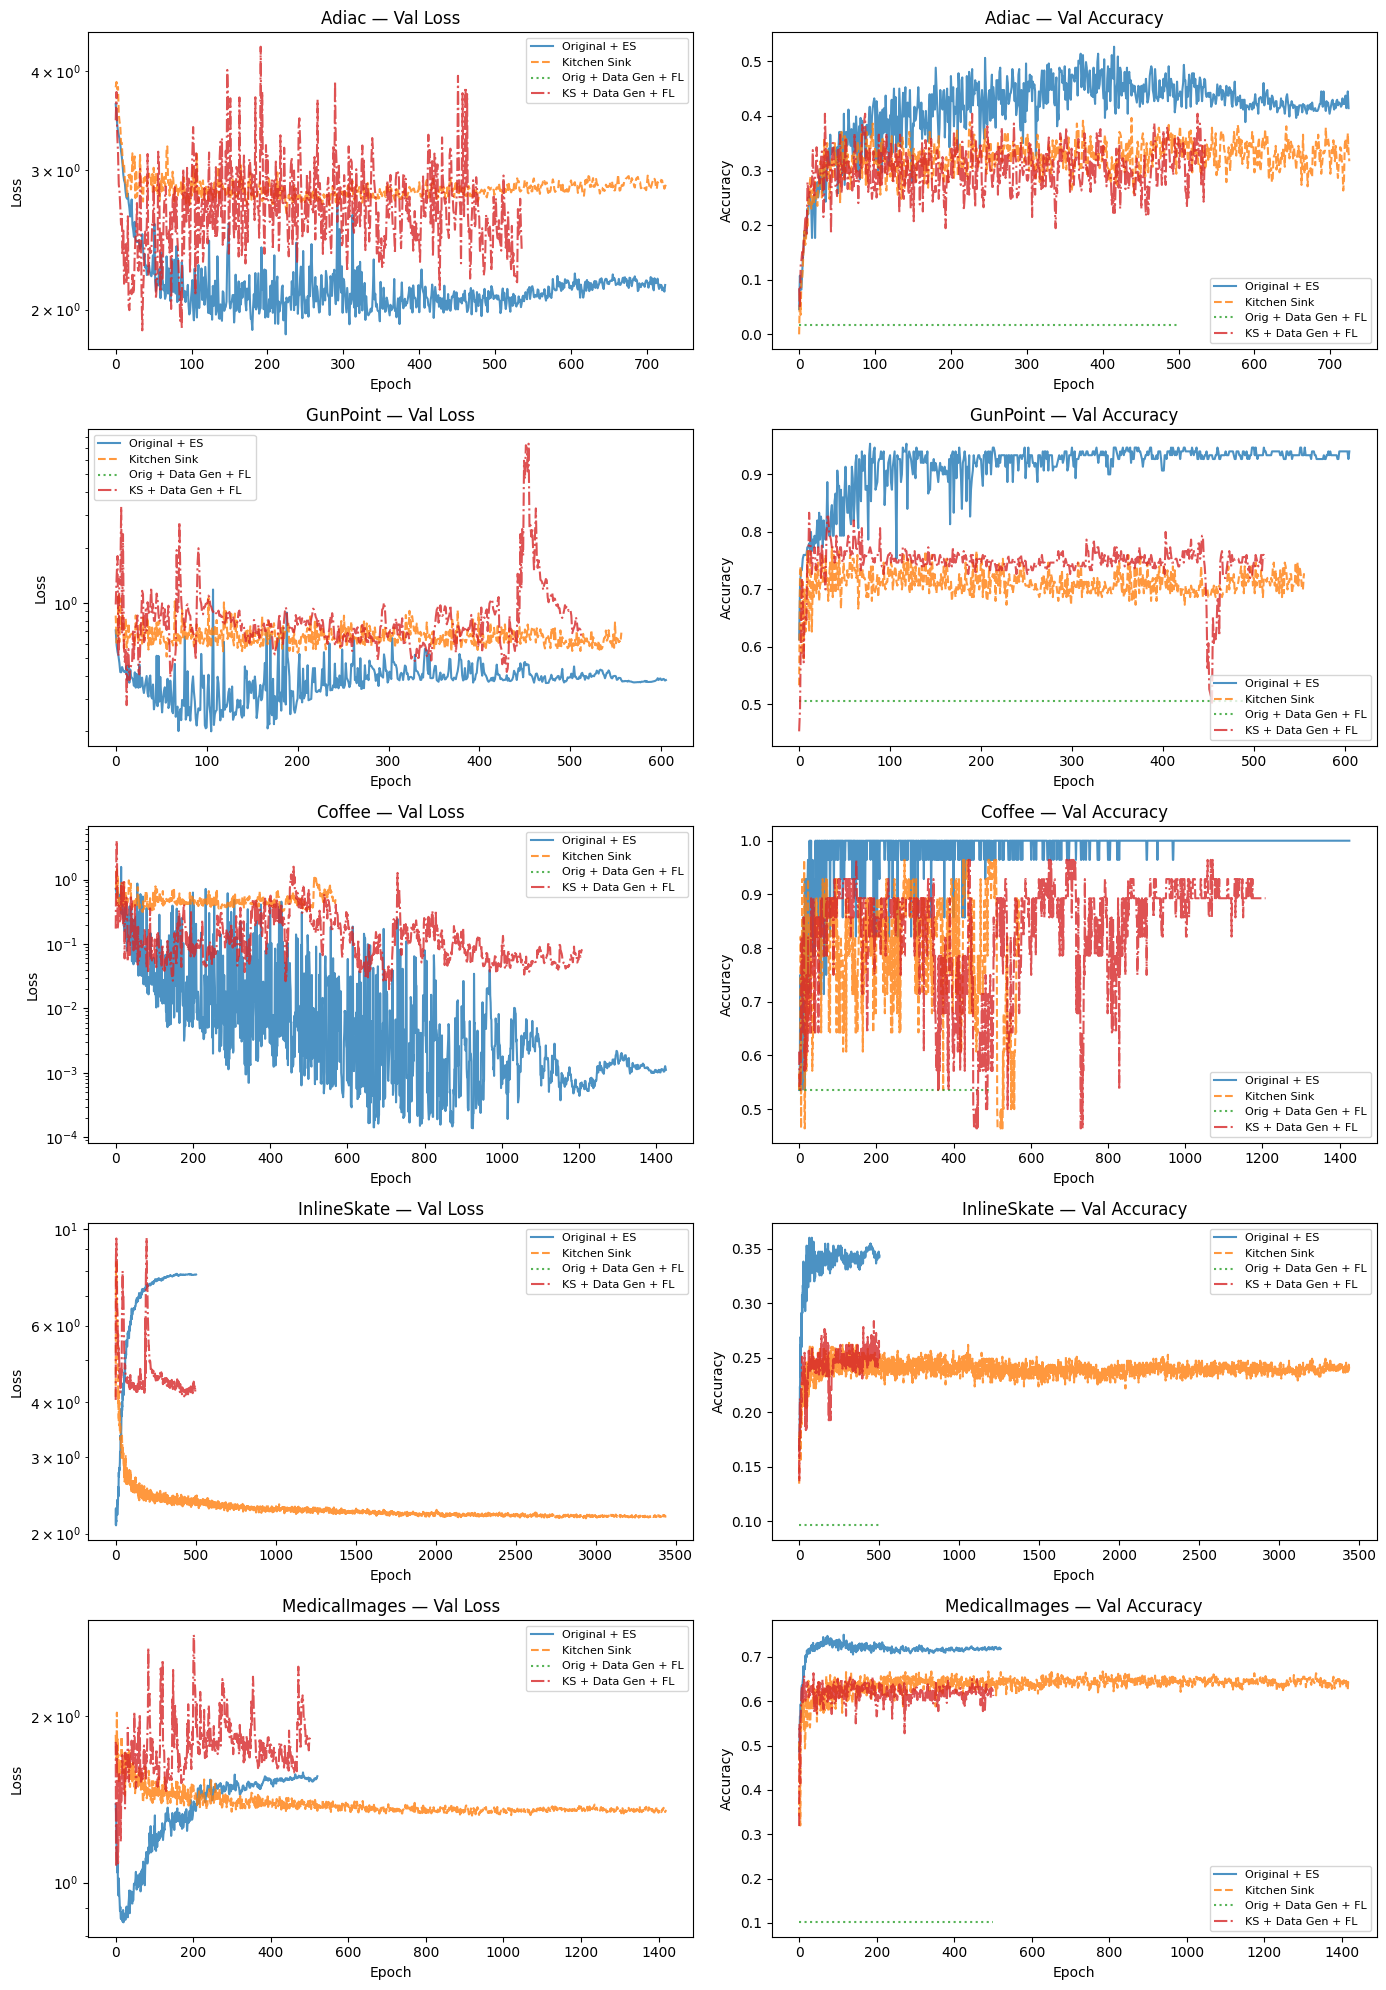

In [18]:
# Training curves — 4-experiment comparison (seed 0)
fig, axes = plt.subplots(len(CONFIG['datasets']), 2,
                         figsize=(14, 4 * len(CONFIG['datasets'])))
if len(CONFIG['datasets']) == 1:
    axes = axes.reshape(1, -1)

for row, ds in enumerate(CONFIG['datasets']):
    h_es = earlystop_results[ds]['all_results'][0]['history']
    h_ks = kitchen_sink_results[ds]['all_results'][0]['history']
    h_df = datagen_focal_results[ds]['all_results'][0]['history']
    h_kd = kitchen_sink_datagen_results[ds]['all_results'][0]['history']

    ax = axes[row, 0]
    ax.plot(h_es['val_loss'], label='Original + ES',       alpha=0.8)
    ax.plot(h_ks['val_loss'], label='Kitchen Sink',        alpha=0.8, ls='--')
    ax.plot(h_df['val_loss'], label='Orig + Data Gen + FL',alpha=0.8, ls=':')
    ax.plot(h_kd['val_loss'], label='KS + Data Gen + FL',  alpha=0.8, ls='-.')
    ax.set_title(f'{ds} — Val Loss'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss'); ax.set_yscale('log'); ax.legend(fontsize=8)

    ax = axes[row, 1]
    ax.plot(h_es['val_accuracy'], label='Original + ES',       alpha=0.8)
    ax.plot(h_ks['val_accuracy'], label='Kitchen Sink',        alpha=0.8, ls='--')
    ax.plot(h_df['val_accuracy'], label='Orig + Data Gen + FL',alpha=0.8, ls=':')
    ax.plot(h_kd['val_accuracy'], label='KS + Data Gen + FL',  alpha=0.8, ls='-.')
    ax.set_title(f'{ds} — Val Accuracy'); ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'mlp_training_curves.png'), dpi=150)
plt.show()


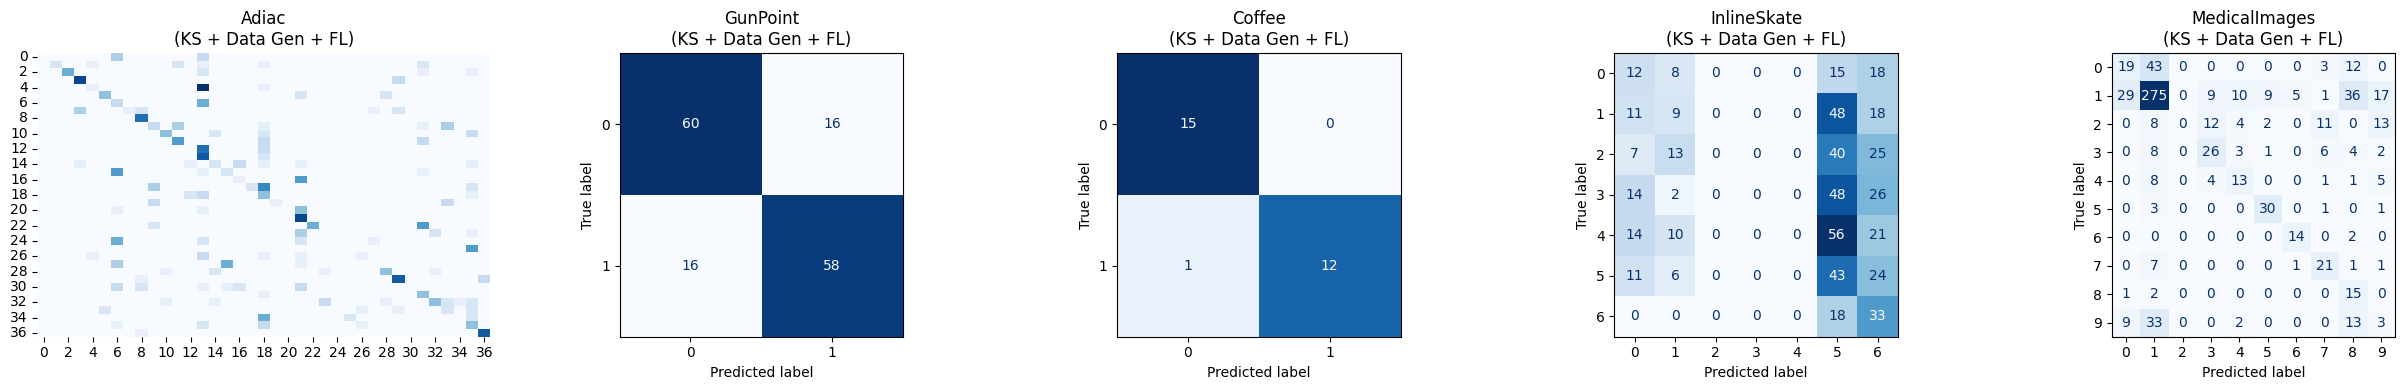

In [19]:
# Confusion matrices (Kitchen Sink + Data Gen + FL, seed 0)
n_ds = len(CONFIG['datasets'])
fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4))
if n_ds == 1: axes = [axes]
for i, ds in enumerate(CONFIG['datasets']):
    best_run = kitchen_sink_datagen_results[ds]['all_results'][0]
    cm = confusion_matrix(best_run['y_test'], best_run['y_pred'])
    nb_classes = data_store[ds]['nb_classes']
    if nb_classes > 10:
        sns.heatmap(cm, ax=axes[i], cmap='Blues', cbar=False)
    else:
        ConfusionMatrixDisplay(cm).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'{ds}\n(KS + Data Gen + FL)')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'mlp_confusion_matrices.png'), dpi=150)
plt.show()


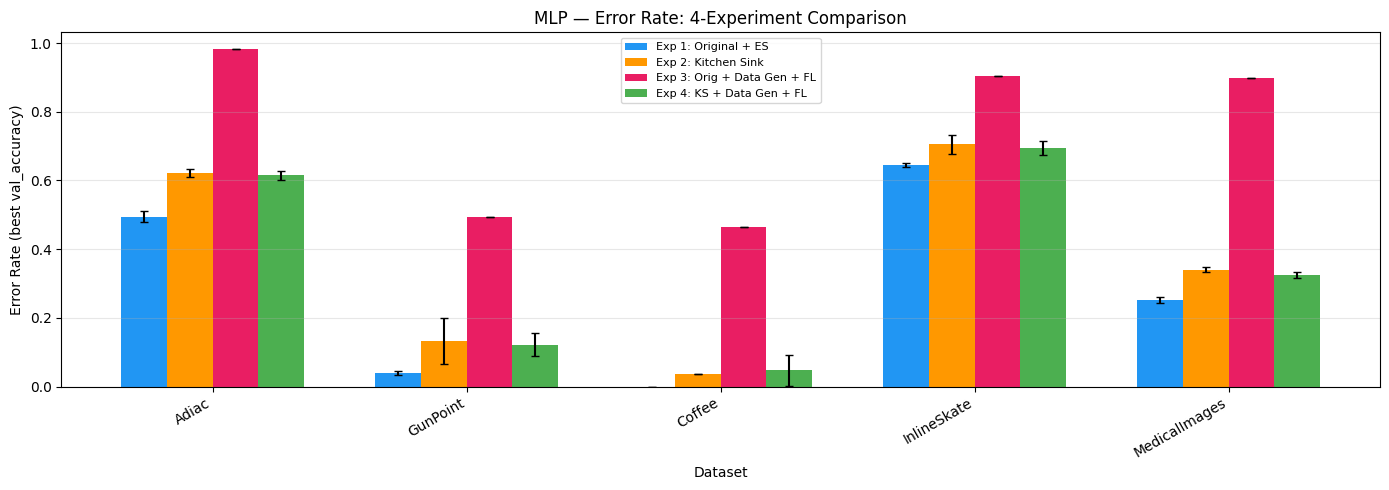

In [20]:
# Bar chart: 4-experiment comparison
datasets = CONFIG['datasets']
x_pos = np.arange(len(datasets))
width = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]
labels  = ['Exp 1: Original + ES', 'Exp 2: Kitchen Sink',
           'Exp 3: Orig + Data Gen + FL', 'Exp 4: KS + Data Gen + FL']
colours = ['#2196F3', '#FF9800', '#E91E63', '#4CAF50']
errors_list = [
    [earlystop_results[ds]['mean_best_val_error']            for ds in datasets],
    [kitchen_sink_results[ds]['mean_best_val_error']         for ds in datasets],
    [datagen_focal_results[ds]['mean_best_val_error']        for ds in datasets],
    [kitchen_sink_datagen_results[ds]['mean_best_val_error'] for ds in datasets],
]
yerrs_list = [
    [earlystop_results[ds]['std_best_val_error']             for ds in datasets],
    [kitchen_sink_results[ds]['std_best_val_error']          for ds in datasets],
    [datagen_focal_results[ds]['std_best_val_error']         for ds in datasets],
    [kitchen_sink_datagen_results[ds]['std_best_val_error']  for ds in datasets],
]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (label, colour, errs, yerrs) in enumerate(zip(labels, colours, errors_list, yerrs_list)):
    ax.bar(x_pos + offsets[i] * width, errs, width,
           label=label, color=colour, yerr=yerrs, capsize=3)

ax.set_xlabel('Dataset'); ax.set_ylabel('Error Rate (best val_accuracy)')
ax.set_title('MLP — Error Rate: 4-Experiment Comparison')
ax.set_xticks(x_pos); ax.set_xticklabels(datasets, rotation=30, ha='right')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_dir'], 'mlp_barchart.png'), dpi=150)
plt.show()


### Per-Class Metrics, MPCE & Save

In [21]:
# Classification reports (Kitchen Sink + Data Gen + FL, seed 0)
for ds in CONFIG['datasets']:
    best_run = kitchen_sink_datagen_results[ds]['all_results'][0]
    print(f"\n{'='*60}")
    print(f"  Classification Report: {ds} (KS + Data Gen + FL MLP)")
    print(f"{'='*60}")
    print(classification_report(best_run['y_test'], best_run['y_pred'],
                                digits=3, zero_division=0))



  Classification Report: Adiac (KS + Data Gen + FL MLP)
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         7
           1      1.000     0.222     0.364         9
           2      1.000     0.600     0.750        10
           3      0.688     0.786     0.733        14
           4      0.333     0.071     0.118        14
           5      0.714     0.556     0.625         9
           6      0.103     0.333     0.158         9
           7      1.000     0.100     0.182        10
           8      0.600     1.000     0.750         9
           9      0.250     0.231     0.240        13
          10      0.714     0.417     0.526        12
          11      0.538     0.538     0.538        13
          12      0.000     0.000     0.000        12
          13      0.179     0.833     0.294        12
          14      0.286     0.200     0.235        10
          15      0.222     0.182     0.200        11
          16      0.167 

In [22]:
# MPCE (paper Equation 4)
def compute_mpce(results_dict, key='mean_error'):
    pce = []
    for ds in CONFIG['datasets']:
        error = results_dict[ds][key]
        pce.append(error / data_store[ds]['nb_classes'])
    return np.mean(pce)

mpce_paper = np.mean([PAPER_MLP_ERRORS[ds] / data_store[ds]['nb_classes']
                      for ds in CONFIG['datasets']])

print("Mean Per-Class Error (MPCE) — lower is better\n")
print(f"  Paper (published)         : {mpce_paper:.5f}")
for vn in [k for k in all_experiments if k != 'Paper']:
    mpce_r = compute_mpce(all_experiments[vn], 'mean_error')
    mpce_b = compute_mpce(all_experiments[vn], 'mean_best_val_error')
    print(f"  {vn:25s}: {mpce_r:.5f} (restored)  {mpce_b:.5f} (best val_acc)")

Mean Per-Class Error (MPCE) — lower is better

  Paper (published)         : 0.03200
  Original + ES            : 0.03826 (restored)  0.03014 (best val_acc)
  Kitchen Sink             : 0.05423 (restored)  0.04721 (best val_acc)
  Original + Data Gen + FL : 0.14486 (restored)  0.14486 (best val_acc)
  KS + Data Gen + FL       : 0.05600 (restored)  0.04666 (best val_acc)


In [23]:
# Save results
rows = []
for ds in CONFIG['datasets']:
    row = {
        'Dataset': ds,
        'Classes': data_store[ds]['nb_classes'],
        'Train_N': data_store[ds]['x_train'].shape[0],
        'Test_N': data_store[ds]['x_test'].shape[0],
        'Length': data_store[ds]['x_train'].shape[1],
        'Paper_Error': PAPER_MLP_ERRORS.get(ds, None),
    }
    for en, ed in all_experiments.items():
        if en == 'Paper': continue
        safe = en.replace('+', '').replace(' ', '_').strip('_')
        row[f'{safe}_Error'] = ed[ds]['mean_error']
        row[f'{safe}_Std']   = ed[ds]['std_error']
        row[f'{safe}_BestValErr'] = ed[ds]['mean_best_val_error']
    rows.append(row)

df = pd.DataFrame(rows)
csv_path = os.path.join(CONFIG['output_dir'], 'mlp_3_0_results.csv')
df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}\n")
df_d = df.copy()
df_d[df_d.select_dtypes('float').columns] = df_d.select_dtypes('float').round(4)
print(df_d.set_index('Dataset').T.to_string())

Results saved to results_3_0/mlp_3_0_results.csv

Dataset                               Adiac  GunPoint    Coffee  InlineSkate  MedicalImages
Classes                             37.0000    2.0000    2.0000       7.0000        10.0000
Train_N                            390.0000   50.0000   28.0000     100.0000       381.0000
Test_N                             391.0000  150.0000   28.0000     550.0000       760.0000
Length                             176.0000  150.0000  286.0000    1882.0000        99.0000
Paper_Error                          0.2480    0.0670    0.0000       0.6490         0.2710
Original__ES_Error                   0.5490    0.0622    0.0000       0.8079         0.2996
Original__ES_Std                     0.0197    0.0031    0.0000       0.0249         0.0108
Original__ES_BestValErr              0.4945    0.0400    0.0000       0.6455         0.2513
Kitchen_Sink_Error                   0.6471    0.1422    0.0833       0.7327         0.3618
Kitchen_Sink_Std              

### Summary of Findings (3.0 — 2× Width)

#### Improvements Applied
- **Early stopping on val_loss** — methodologically sounder than min training loss
- **BatchNorm + LeakyReLU** — stabilises training, prevents dying neurons
- **Label smoothing** — reduces overconfidence on small training sets
- **Class weighting** — addresses MedicalImages imbalance (6 vs 203 samples)
- **Jitter + scaling augmentation** — regularisation via input noise and amplitude variation
- **Mixup augmentation** — virtual sample creation via interpolation; strong regulariser
- **Wider layers (1500 units in 3.0, was 750)** — 2× width Kitchen Sink — more capacity, offset by our added regularisation
- **Adam optimiser** — already used for FCN/ResNet in the same paper
- **Cosine annealing LR** available via CONFIG toggle